<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/CNN_Flower.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Yêu cầu cụ thể: Mô hình CNN**


# MÔ HÌNH XÂY DỰNG

Input: 128 × 128 × 3

→ Conv2D (32 filters, 3×3) + ReLU
→ MaxPooling2D (2×2)

→ Conv2D (64 filters, 3×3) + ReLU
→ MaxPooling2D (2×2)

→ Flatten
→ Dense (128) + ReLU
→ Dense (5) + Softmax

- Conv2D: trích xuất đặc trưng (edges, textures, shapes)
- MaxPooling2D: giảm chiều dữ liệu, giữ đặc trưng quan trọng
- Flatten: chuyển tensor 2D → vector 1D
- Dense: học quan hệ phi tuyến để phân loại

# 🌸 BƯỚC 1 — IMPORT THƯ VIỆN

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# 📂 BƯỚC 2 — LOAD DATA

In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "hoangdanghh",\n  "key": "KGAT_bce95034826acd32eabc1a214989b034"\n}'}

In [3]:
import os

# tạo thư mục kaggle
os.makedirs("/root/.kaggle", exist_ok=True)

# di chuyển file kaggle.json vào đúng chỗ
!cp kaggle.json /root/.kaggle/

# cấp quyền
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d alxmamaev/flowers-recognition

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:01<00:00, 141MB/s]



In [5]:
!unzip flowers-recognition.zip -d flowers

Archive:  flowers-recognition.zip
  inflating: flowers/flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: flowers/flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: flowers/flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: flowers/flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: flowers/flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: flowers/flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: flowers/flowers/daisy/10300722094_28fa978807_n.jpg  
  inflating: flowers/flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: flowers/flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: flowers/flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: flowers/flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: flowers/flowers/daisy/10437929963_bc13eebe0c.jpg  
  inflating: flowers/flowers/daisy/10466290366_cc72e33532.jpg  
  inflating: flowers/flowers/daisy/10466558316_a7198b87e2.jpg  
  inflating: flowers/flowers/daisy/10555749515_13a12a026e.jpg

In [6]:
import os

base_dir = "/content/flowers"

for folder in os.listdir(base_dir):
    print(folder, ":", len(os.listdir(os.path.join(base_dir, folder))))

flowers : 5


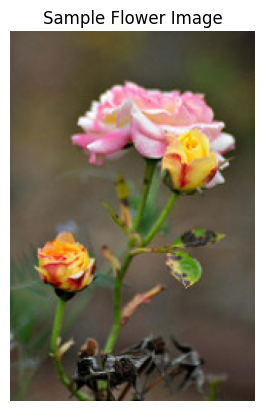

In [8]:
import matplotlib.pyplot as plt
import cv2
import os

sample_path = "/content/flowers/flowers/rose"
img_name = os.listdir(sample_path)[0]

img = cv2.imread(os.path.join(sample_path, img_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Flower Image")
plt.axis("off")
plt.show()

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 3454 images belonging to 1 classes.
Found 863 images belonging to 1 classes.


# kiểm tra folder

In [24]:
base_dir = "/content/flowers/flowers"

# 📊 Kiểm tra dữ liệu

In [46]:
for folder in os.listdir(base_dir):
    path = os.path.join(base_dir, folder)
    print(folder, ":", len(os.listdir(path)))

dandelion : 1052
daisy : 764
rose : 784
sunflower : 733
tulip : 984


# 🧪 BƯỚC 3 — PREPROCESS DATA

# Chuẩn hóa ảnh + chia train/validation

In [47]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Train set

In [48]:
train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 3457 images belonging to 5 classes.


# Validation set

In [49]:
val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 860 images belonging to 5 classes.


### Verify Class Labels and Counts

In [50]:
# Check the class indices inferred by the ImageDataGenerator
print("Class Indices (from train_data):", train_data.class_indices)
print("Class Indices (from val_data):", val_data.class_indices)

# Count the number of classes detected by Keras
num_classes_train = len(train_data.class_indices)
num_classes_val = len(val_data.class_indices)
print(f"Number of classes detected in training data: {num_classes_train}")
print(f"Number of classes detected in validation data: {num_classes_val}")

# Verify the number of subdirectories in the corrected base_dir
import os
corrected_base_dir = "/content/flowers/flowers" # This should be the actual path where your class folders are
actual_class_folders = [f for f in os.listdir(corrected_base_dir) if os.path.isdir(os.path.join(corrected_base_dir, f))]
num_actual_classes = len(actual_class_folders)
print(f"Actual number of class subdirectories: {num_actual_classes}")
print(f"Actual class folders: {actual_class_folders}")

Class Indices (from train_data): {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Class Indices (from val_data): {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Number of classes detected in training data: 5
Number of classes detected in validation data: 5
Actual number of class subdirectories: 5
Actual class folders: ['dandelion', 'daisy', 'rose', 'sunflower', 'tulip']


# 🧠 BƯỚC 4 — XÂY DỰNG CNN (FROM SCRATCH)

In [31]:
model = models.Sequential()

# 📌 Conv Block 1

In [32]:
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 📌 Conv Block 2

In [33]:
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# 📌 Conv Block 3

In [34]:
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# 📌 Fully Connected

In [35]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(5, activation='softmax'))

# 🧾 BƯỚC 5 — COMPILE MODEL

In [36]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🏋️ BƯỚC 6 — TRAIN MODEL

In [37]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.4293 - loss: 1.3046 - val_accuracy: 0.5279 - val_loss: 1.1374
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.5884 - loss: 1.0233 - val_accuracy: 0.6070 - val_loss: 1.0279
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.6520 - loss: 0.8829 - val_accuracy: 0.6233 - val_loss: 0.9540
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7136 - loss: 0.7456 - val_accuracy: 0.6349 - val_loss: 0.9567
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7547 - loss: 0.6356 - val_accuracy: 0.6826 - val_loss: 0.8995
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8195 - loss: 0.4789 - val_accuracy: 0.6570 - val_loss: 1.0060
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8794 - loss: 0.3294 - val_accuracy: 0.6547 - val_loss: 1.1112
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9268 - loss: 0.2131 - val_accu

# 📈 BƯỚC 7 — VẼ ACCURACY / LOSS

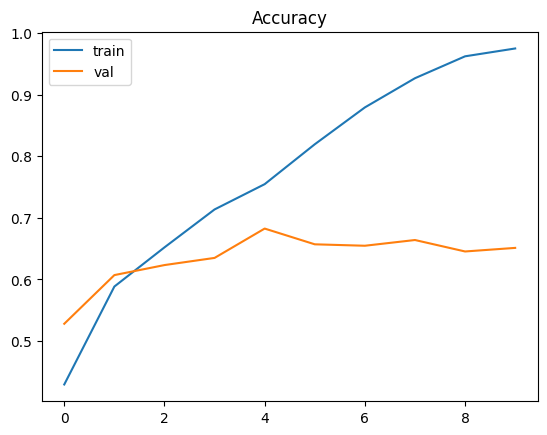

In [38]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

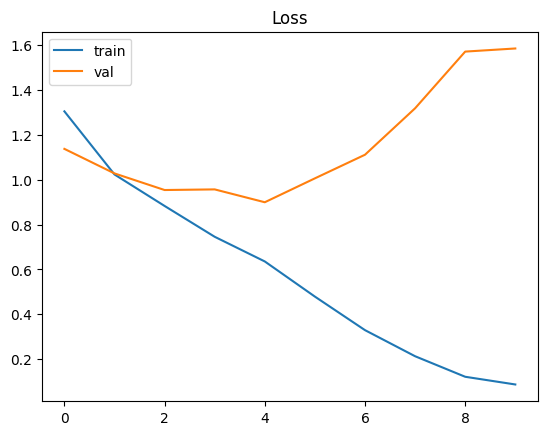

In [39]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

# **🎯 BƯỚC 8. — FEATURE MAP**
(thực hiện sau bước 6)

8.1 Tạo feature extractor model

8.2 Lấy 1 ảnh test

8.3 Predict feature maps

6.4 Visualize feature maps

**TRÍCH Conv2D Layer 1**

8.1 Tạo feature extractor model


In [53]:
from tensorflow.keras.models import Model
feature_model = Model(
    inputs=model.inputs[0],
    outputs=model.get_layer("conv2d_3").output
)

6.2 Lấy 1 ảnh test

In [54]:
img_batch, label = next(train_data)
img = img_batch[0]

6.3 Predict feature maps

In [55]:
feature_maps = feature_model.predict(np.expand_dims(img, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


6.4 Visualize feature maps

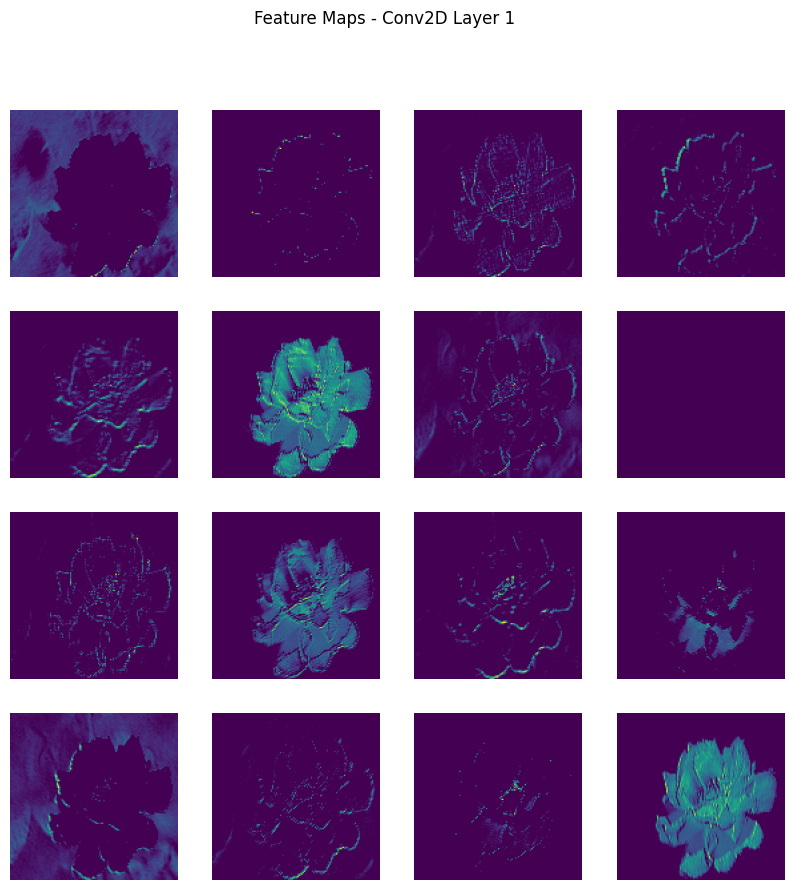

In [56]:
plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Feature Maps - Conv2D Layer 1")
plt.show()

# Feature Maps cho Conv Layer 2 và Conv Layer 3
- BƯỚC 1 — TẠO FEATURE MODEL CHO NHIỀU LAYER
- BƯỚC 2 — LẤY ẢNH INPUT
- BƯỚC 3 — PREDICT FEATURE MAPS
- BƯỚC 4 — VISUALIZE CONV LAYER 2
- BƯỚC 5 — VISUALIZE CONV LAYER 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


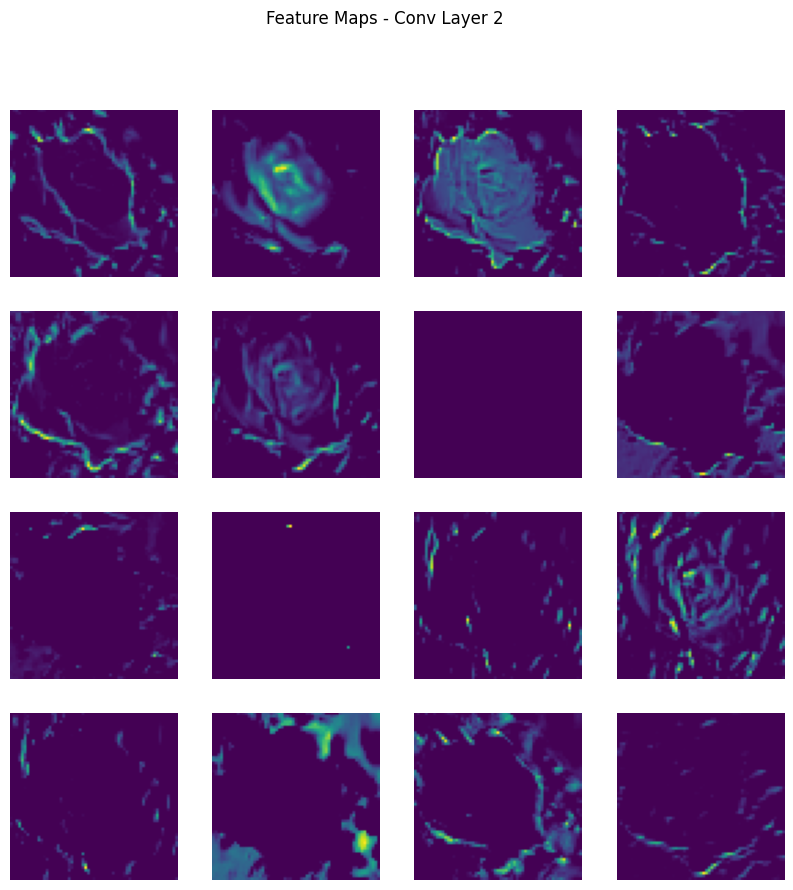

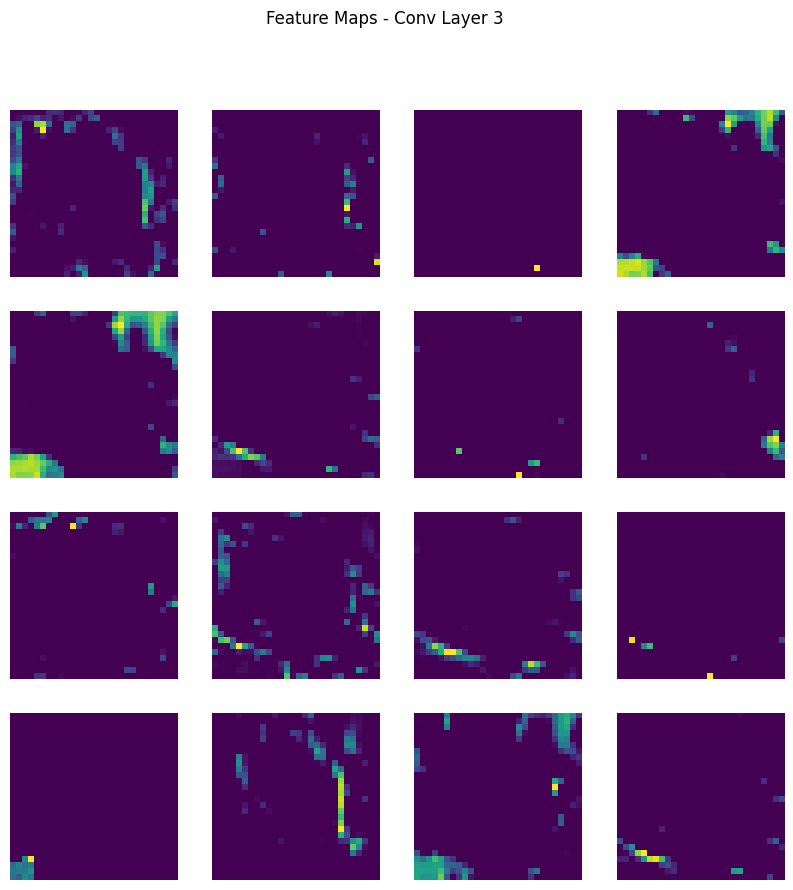

In [58]:
# Bước 1
from tensorflow.keras.models import Model

layer_outputs = [
    model.get_layer(index=0).output,  # Conv1
    model.get_layer(index=2).output,  # Conv2
    model.get_layer(index=4).output   # Conv3
]

feature_model = Model(inputs=model.inputs[0], outputs=layer_outputs)

# Bước 2
img_batch, label = next(train_data)
img = img_batch[0]

# Bước 3
feature_maps = feature_model.predict(
    np.expand_dims(img, axis=0)
)

# Bước 4 visualize layer 2
import matplotlib.pyplot as plt

conv2 = feature_maps[1]

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(conv2[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Feature Maps - Conv Layer 2")
plt.show()

# Bước 5 visualize layer 3
conv3 = feature_maps[2]

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(conv3[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Feature Maps - Conv Layer 3")
plt.show()

# 🧮 BƯỚC 8 — TÍNH OUTPUT SHAPE

📌 Conv1

Input: 128×128×3
Kernel: 3×3

Output = (128 - 3)/1 + 1 = 126

📌 Conv2

Input: 126×126×32
Output = 124 × 124 × 64

📌 Conv3

(3×3×32 + 1) × 64 = 18496

# 🎨 BƯỚC 10 — FEATURE MAPS

📌 Tạo model trích feature maps

In [41]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = models.Model(inputs=model.inputs[0], outputs=layer_outputs)

📌 Lấy ảnh test

In [42]:
img, label = next(train_data)
activations = activation_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


# 🟢 Visualize Conv1

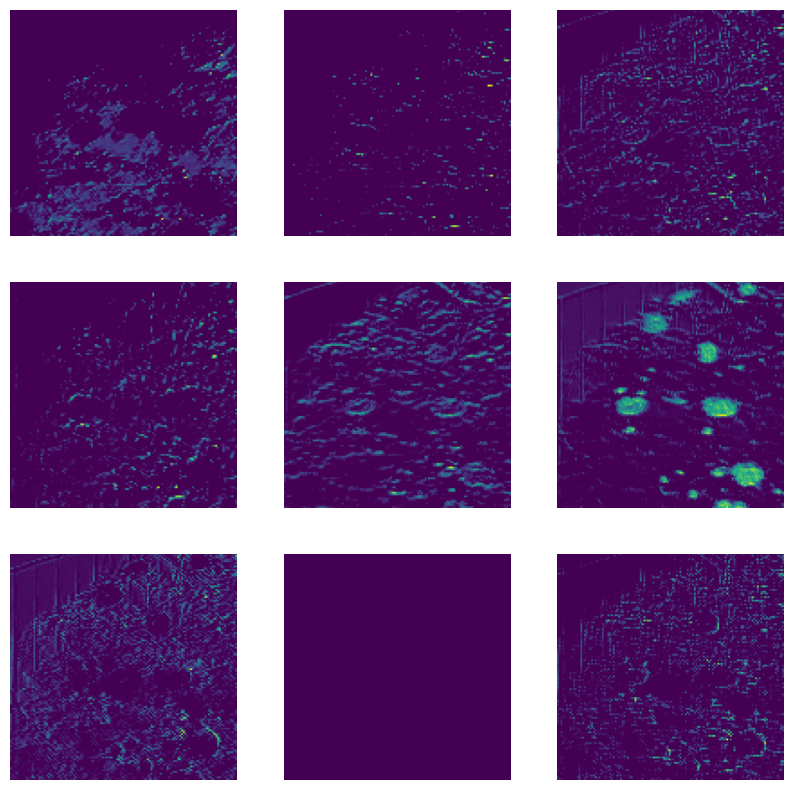

In [43]:
first_layer = activations[0]

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(first_layer[0,:,:,i], cmap='viridis')
    plt.axis('off')
plt.show()

# 🔴 Visualize Conv3

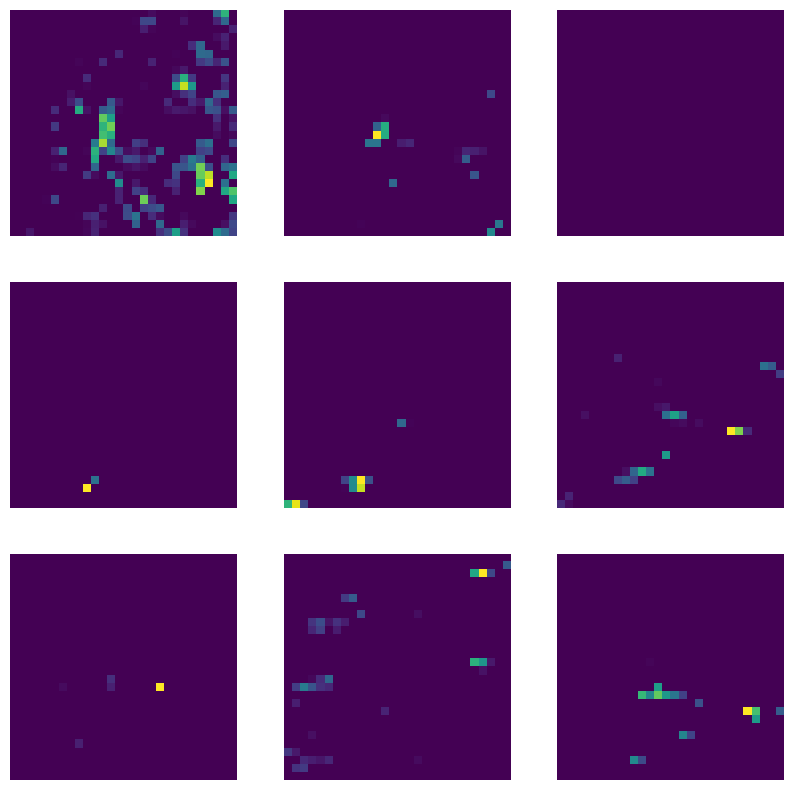

In [44]:
third_layer = activations[2]

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(third_layer[0,:,:,i], cmap='viridis')
    plt.axis('off')
plt.show()